# 21 - Generate Power BI Assets

## Purpose

This notebook generates all the reporting assets required by the Power BI dashboard from the saved production model.

### Outputs

- metrics.csv
- classification_report.csv
- confusion_matrix.csv
- feature_importance.csv
- roc_curve.csv
- roc_curve.png
- precision_recall_curve.csv
- precision_recall_curve.png
- model_info.csv
- dashboard_summary.json

This notebook **does not retrain the model**. It only evaluates the saved model and exports assets for reporting.

# Section 1 — Imports

Import all required libraries for:

- Data handling
- Model loading
- Evaluation metrics
- Visualization
- Exporting Power BI assets

In [4]:
# ============================================
# Section 1 - Imports
# ============================================

import os
import json
from datetime import datetime

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Plot settings
plt.style.use("default")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

print("Libraries imported successfully.")

Libraries imported successfully.


# Section 0 — Logging

Configure application logging.

Every execution of this notebook creates a log file that records:

- Execution start
- Model information
- Errors (if any)
- Generated assets
- Completion status

In [5]:
# ============================================
# Section 0 - Logging
# ============================================

import logging

LOG_DIR = "../logs"

os.makedirs(LOG_DIR, exist_ok=True)

LOG_FILE = os.path.join(
    LOG_DIR,
    "powerbi_asset_generation.log"
)

logging.basicConfig(

    filename=LOG_FILE,

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    filemode="a"

)

logging.info("=" * 80)
logging.info("Power BI Asset Generation Started")
logging.info("=" * 80)

print("Logging initialized.")

Logging initialized.


# Section 2 — Project Configuration

Configure all project paths in one place.

Keeping paths centralized makes the notebook easier to maintain if the project structure changes.

In [6]:


MODEL_PATH = "../models/best_model.pkl"

METADATA_PATH = "../models/best_model_metadata.json"

X_TEST_PATH = "../data/processed/X_test.csv"

Y_TEST_PATH = "../data/processed/y_test.csv"

OUTPUT_DIR = "../powerbi_assets"

# Section 3 — Verify Required Files

Before running the evaluation, verify that all required files exist.

This prevents runtime errors caused by missing models or datasets.

In [7]:
# ============================================
# Section 3 - Verify Required Files
# ============================================


required_files = [

    MODEL_PATH,

    METADATA_PATH,

    X_TEST_PATH,

    Y_TEST_PATH

]

missing_files = []

for file in required_files:
    if not os.path.exists(file):
        missing_files.append(file)

if missing_files:
    print("Missing required files:\n")
    for file in missing_files:
        print(f"❌ {file}")
    raise FileNotFoundError(
        "One or more required files are missing."
    )

print("All required project files were found.")

All required project files were found.


# Section 4 — Load Model & Test Dataset

Load the production model and the test dataset used for evaluation.

This notebook never retrains the model. It only evaluates the saved production model.

In [8]:
# ============================================
# Section 4 - Load Model & Test Data
# ============================================

print("=" * 60)
print("Loading Production Model")
print("=" * 60)

model = joblib.load(MODEL_PATH)
logging.info(f"Loaded Model : {type(model).__name__}")

print(f"Model Loaded: {type(model).__name__}")

print("\nLoading Test Dataset...")

X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print(f"X_test Shape : {X_test.shape}")
print(f"y_test Shape : {y_test.shape}")


print("\nDataset Loaded Successfully.")

logging.info(f"Testing Samples : {len(X_test)}")
logging.info(f"Features : {X_test.shape[1]}")

Loading Production Model
Model Loaded: RandomForestClassifier

Loading Test Dataset...
X_test Shape : (56746, 33)
y_test Shape : (56746,)

Dataset Loaded Successfully.


# Section 5 — Generate Predictions

Generate predictions and prediction probabilities using the saved production model.

In [9]:
# ============================================
# Section 5 - Generate Predictions
# ============================================

print("=" * 60)
print("Generating Predictions")
print("=" * 60)

y_pred = model.predict(X_test)

if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    y_prob = y_pred

print("Predictions Generated Successfully.")

Generating Predictions
Predictions Generated Successfully.


# Section 6 — Model Evaluation Metrics

Calculate all evaluation metrics that will be displayed in the Power BI dashboard.

In [10]:
# ============================================
# Section 6 - Evaluation Metrics
# ============================================

metrics = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Log Loss",
        "Matthews Correlation"

    ],

    "Value": [

        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        log_loss(y_test, y_prob),
        matthews_corrcoef(y_test, y_pred)

    ]

})

metrics

,Metric,Value
0,Accuracy,0.9995
1,Balanced Accuracy,0.8631
2,Precision,0.9583
3,Recall,0.7263
4,F1 Score,0.8263
5,ROC-AUC,0.9439
6,Log Loss,0.0080
7,Matthews Correlation,0.8341


# Section 7 — Export Metrics

Export all key evaluation metrics for Power BI.

In [12]:
# ============================================
# Section 7 - Export Metrics
# ============================================

metrics.to_csv(
    os.path.join(OUTPUT_DIR, "metrics.csv"),
    index=False
)

print("metrics.csv exported successfully.")
logging.info("metrics.csv exported.")

metrics.csv exported successfully.


# Section 8 — Classification Report

Generate the complete classification report.

In [13]:
# ============================================
# Section 8 - Classification Report
# ============================================

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

classification_df = pd.DataFrame(report).transpose()

classification_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "classification_report.csv"
    )
)

classification_df

logging.info("classification_report.csv exported.")

# Section 9 — Confusion Matrix

Generate the confusion matrix for Power BI and GitHub documentation.

In [14]:
# ============================================
# Section 9 - Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

confusion_df = pd.DataFrame({

    "Actual": [

        "Genuine",
        "Genuine",
        "Fraud",
        "Fraud"

    ],

    "Predicted": [

        "Genuine",
        "Fraud",
        "Genuine",
        "Fraud"

    ],

    "Count": [

        cm[0,0],
        cm[0,1],
        cm[1,0],
        cm[1,1]

    ]

})

confusion_df

,Actual,Predicted,Count
0,Genuine,Genuine,56648
1,Genuine,Fraud,3
2,Fraud,Genuine,26
3,Fraud,Fraud,69


In [15]:
# ============================================
# Section 10 - Export Confusion Matrix
# ============================================

confusion_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "confusion_matrix.csv"
    ),
    index=False
)

print("confusion_matrix.csv exported.")
logging.info("confusion_matrix.csv exported.")

confusion_matrix.csv exported.


In [16]:
# ============================================
# Section 11 - Feature Importance
# ============================================

if hasattr(model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": X_test.columns,

        "Importance": model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    feature_importance.to_csv(

        os.path.join(
            OUTPUT_DIR,
            "feature_importance.csv"
        ),

        index=False

    )

feature_importance.head(10)
logging.info("feature_importance.csv exported.")

In [17]:
# ============================================
# Section 12 - ROC Curve
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_df = pd.DataFrame({

    "False Positive Rate": fpr,

    "True Positive Rate": tpr,

    "Threshold": thresholds

})

roc_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "roc_curve.csv"
    ),
    index=False
)

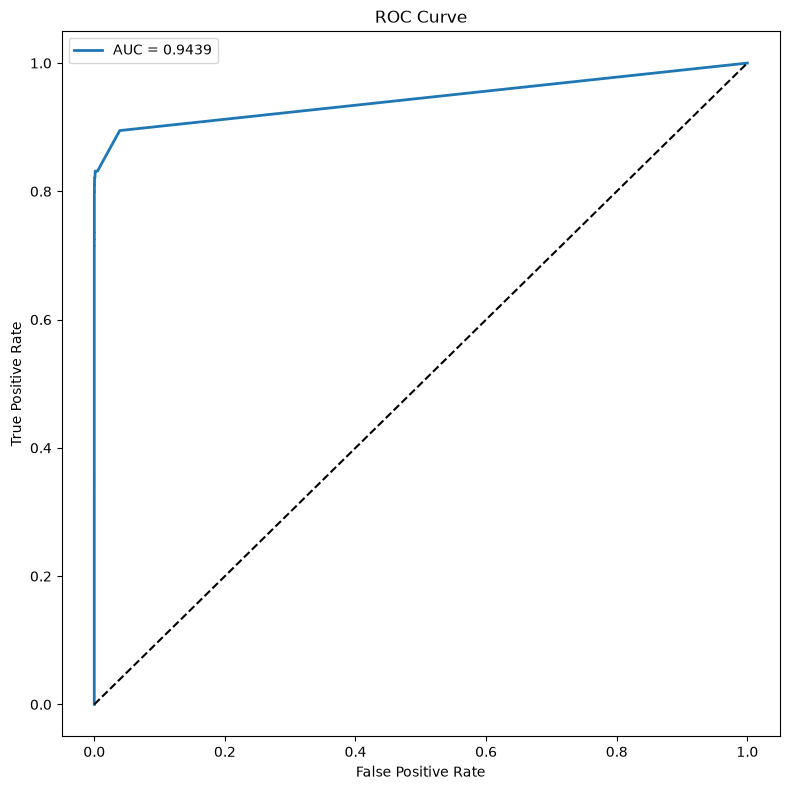

In [18]:
# ============================================
# Section 13 - ROC Curve Plot
# ============================================

plt.figure(figsize=(8,8))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.4f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "roc_curve.png"
    ),
    dpi=300
)

plt.show()
logging.info("roc_curve.png exported.")

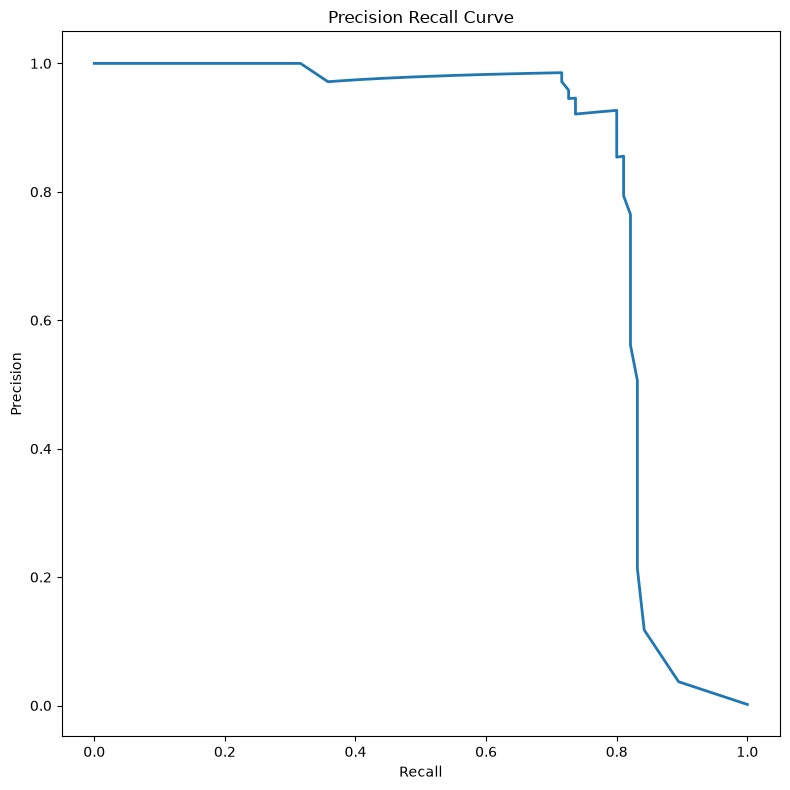

In [19]:
# ============================================
# Section 14 - Precision Recall Curve
# ============================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_df = pd.DataFrame({

    "Precision": precision[:-1],

    "Recall": recall[:-1],

    "Threshold": thresholds

})

pr_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "precision_recall_curve.csv"
    ),
    index=False
)

plt.figure(figsize=(8,8))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "precision_recall_curve.png"
    ),
    dpi=300
)

plt.show()
logging.info("precision_recall_curve.png exported.")

In [20]:
# ============================================
# Section 15 - Model Information
# ============================================

model_info = pd.DataFrame({

    "Property":[

        "Model",
        "Algorithm",
        "Features",
        "Testing Samples",
        "Generated On"

    ],

    "Value":[

        "Best Model",
        type(model).__name__,
        len(X_test.columns),
        len(X_test),
        datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    ]

})

model_info.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_info.csv"
    ),
    index=False
)

model_info
logging.info("model_info.csv exported.")

In [21]:
# ============================================
# Section 16 - Summary
# ============================================

print("=" * 60)
print("POWER BI ASSETS GENERATED SUCCESSFULLY")
print("=" * 60)

for file in sorted(os.listdir(OUTPUT_DIR)):
    print(f"✓ {file}")

print("=" * 60)

POWER BI ASSETS GENERATED SUCCESSFULLY
✓ classification_report.csv
✓ confusion_matrix.csv
✓ feature_importance.csv
✓ metrics.csv
✓ model_info.csv
✓ precision_recall_curve.csv
✓ precision_recall_curve.png
✓ roc_curve.csv
✓ roc_curve.png


# Section 15.5 — Validate Production Model

Before exporting assets, verify that the production model and its metadata are consistent.

This prevents situations where:

- The wrong model is evaluated.
- Metadata and model become out of sync.
- Power BI reports incorrect information.

In [22]:
# ============================================
# Section 15.5 - Validate Production Model
# ============================================

print("=" * 60)
print("Validating Production Model")
print("=" * 60)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("Metadata Loaded Successfully.\n")

print(f"Saved Model       : {metadata.get('model_name', 'Unknown')}")
print(f"Training Date     : {metadata.get('saved_on', 'Unknown')}")
print(f"Expected Features : {metadata.get('n_features', 'Unknown')}")

print("\nChecking Feature Count...")

expected_features = metadata.get("n_features", len(X_test.columns))
current_features = len(X_test.columns)

if expected_features == current_features:
    print("PASS - Feature count matches.")
else:
    print("WARNING - Feature count mismatch!")
    print(f"Metadata : {expected_features}")
    print(f"Current  : {current_features}")

print("\nChecking Model Type...")

print(type(model).__name__)

print("\nValidation Completed.")

Validating Production Model
Metadata Loaded Successfully.

Saved Model       : Random Forest (Class Weights)
Training Date     : 2026-07-11 20:13:28
Expected Features : Unknown

Checking Feature Count...
PASS - Feature count matches.

Checking Model Type...
RandomForestClassifier

Validation Completed.


In [23]:
print("\nComparing Stored Metrics")

metric_mapping = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

tolerance = 1e-4

for metric_name, current_value in metric_mapping.items():

    saved_value = metadata.get(metric_name)

    if saved_value is None:
        print(f"{metric_name:<20} Not Found in Metadata")
        continue

    difference = abs(saved_value - current_value)

    if difference < tolerance:
        print(f"{metric_name:<20} PASS")
    else:
        print(
            f"{metric_name:<20} WARNING "
            f"(Saved={saved_value:.4f}, Current={current_value:.4f})"
        )


Comparing Stored Metrics
Accuracy             Not Found in Metadata
Precision            Not Found in Metadata
Recall               Not Found in Metadata
F1 Score             Not Found in Metadata
ROC-AUC              Not Found in Metadata


In [24]:
dashboard_summary = {

    "Model": type(model).__name__,

    "Generated On": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "Testing Samples": int(len(X_test)),

    "Features": int(len(X_test.columns)),

    "Metrics": {

        "Accuracy": float(accuracy_score(y_test, y_pred)),
        "Balanced Accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "Precision": float(precision_score(y_test, y_pred)),
        "Recall": float(recall_score(y_test, y_pred)),
        "F1 Score": float(f1_score(y_test, y_pred)),
        "ROC-AUC": float(roc_auc_score(y_test, y_prob)),
        "Log Loss": float(log_loss(y_test, y_prob)),
        "Matthews Correlation": float(matthews_corrcoef(y_test, y_pred))

    }

}

with open(

    os.path.join(
        OUTPUT_DIR,
        "dashboard_summary.json"
    ),

    "w"

) as f:

    json.dump(
        dashboard_summary,
        f,
        indent=4
    )

logging.info("dashboard_summary.json exported.")

# Section 17 — Completion Summary

This section verifies that every required Power BI asset has been successfully generated.

If all files exist, the notebook is ready for Power BI refresh.

In [25]:
# ============================================
# Section 17 - Completion Summary
# ============================================

print("=" * 70)
print("         POWER BI ASSET GENERATION COMPLETE")
print("=" * 70)

required_assets = [

    "metrics.csv",

    "classification_report.csv",

    "confusion_matrix.csv",

    "feature_importance.csv",

    "roc_curve.csv",

    "roc_curve.png",

    "precision_recall_curve.csv",

    "precision_recall_curve.png",

    "model_info.csv",

    "dashboard_summary.json"

]

generated = 0

for asset in required_assets:

    asset_path = os.path.join(OUTPUT_DIR, asset)

    if os.path.exists(asset_path):

        print(f"✓ {asset}")

        generated += 1

    else:

        print(f"✗ {asset}")

print("-" * 70)

print(f"Total Files Generated : {generated}/{len(required_assets)}")

print(f"Output Directory      : {os.path.abspath(OUTPUT_DIR)}")

print("-" * 70)

print("Production Model      :", type(model).__name__)

print("Testing Samples       :", len(X_test))

print("Number of Features    :", X_test.shape[1])

print("Generated On          :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

print("-" * 70)

if generated == len(required_assets):

    print("STATUS : READY FOR POWER BI REFRESH")

else:

    print("STATUS : SOME FILES ARE MISSING")

print("=" * 70)

logging.info(f"Generated {generated} assets.")

         POWER BI ASSET GENERATION COMPLETE
✓ metrics.csv
✓ classification_report.csv
✓ confusion_matrix.csv
✓ feature_importance.csv
✓ roc_curve.csv
✓ roc_curve.png
✓ precision_recall_curve.csv
✓ precision_recall_curve.png
✓ model_info.csv
✓ dashboard_summary.json
----------------------------------------------------------------------
Total Files Generated : 10/10
Output Directory      : /Users/yaseen/Data_Analysis/Project_Files/Financial_Fraud_Detection/powerbi_assets
----------------------------------------------------------------------
Production Model      : RandomForestClassifier
Testing Samples       : 56746
Number of Features    : 33
Generated On          : 2026-07-12 22:42:32
----------------------------------------------------------------------
STATUS : READY FOR POWER BI REFRESH


# Section 18 — Next Steps

After successfully generating the Power BI assets:

1. Open Power BI Desktop.
2. Refresh all data sources.
3. Verify KPI cards update with the latest metrics.
4. Verify the confusion matrix and feature importance visuals.
5. Verify the ROC curve image.
6. Save the updated dashboard.
7. Commit the generated assets and dashboard changes to Git.

In [26]:
# ============================================
# Section 18 - Next Steps
# ============================================

print("\nNEXT STEPS")
print("=" * 70)

steps = [

    "Open Power BI Desktop",

    "Refresh all imported data",

    "Verify KPI cards",

    "Verify Confusion Matrix",

    "Verify Feature Importance",

    "Verify ROC Curve",

    "Save the Power BI Dashboard",

    "Commit changes to Git",

    "Push to GitHub"

]

for i, step in enumerate(steps, start=1):

    print(f"{i}. {step}")

print("=" * 70)

print("Notebook Execution Completed Successfully.")


NEXT STEPS
1. Open Power BI Desktop
2. Refresh all imported data
3. Verify KPI cards
4. Verify Confusion Matrix
5. Verify Feature Importance
6. Verify ROC Curve
7. Save the Power BI Dashboard
8. Commit changes to Git
9. Push to GitHub
Notebook Execution Completed Successfully.


In [27]:
logging.info("Notebook Completed Successfully.")
logging.info("=" * 80)